In [1]:
import os
os.environ["KERAS_BACKEND"] = "tensorflow"

import keras
from keras import layers

import numpy as np
import matplotlib.pyplot as plt

In [2]:
from keras import backend as K
print(K.backend())

tensorflow


In [55]:
from tensorflow.keras.datasets import cifar10

(x_train, y_train), (x_test, y_test) = cifar10.load_data()

# Normalize 0–255 → 0–1
#RGB 0=Musta 255=valkoinen
x_train = x_train.astype("float32") / 255
x_test = x_test.astype("float32") / 255

In [56]:
# 32x32 RGB → flatten (3072)
x_train = x_train.reshape(len(x_train), -1)
x_test = x_test.reshape(len(x_test), -1)

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)


Train shape: (50000, 3072)
Test shape: (10000, 3072)


In [61]:
#Model
model = keras.Sequential([
    layers.Input(shape=(3072,)),      # flat RGB image
    layers.Dense(1024, activation="relu"),
    layers.Dropout(0.15),
    layers.Dense(512, activation="relu"),
    layers.Dropout(0.1),
    layers.Dense(10, activation="softmax")  # CIFAR-10 = 10 luokkaa
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 1024)                │       3,146,752 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 1024)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 512)                 │         524,800 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 10)                  │           5,130 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,676,682 (14.03 MB)

 Trainable params: 3,676,682 (14.03 MB)

 Non-trainable params: 0 (0.00 B)

In [62]:
history = model.fit(
    x_train, y_train,
    validation_split=0.1,
    epochs=18,
    batch_size=256,
    verbose=2
)

Epoch 1/18
176/176 - 5s - 28ms/step - accuracy: 0.2656 - loss: 2.0977 - val_accuracy: 0.3576 - val_loss: 1.8065
Epoch 2/18
176/176 - 4s - 24ms/step - accuracy: 0.3648 - loss: 1.7699 - val_accuracy: 0.3968 - val_loss: 1.6919
Epoch 3/18
176/176 - 4s - 24ms/step - accuracy: 0.3912 - loss: 1.6995 - val_accuracy: 0.4182 - val_loss: 1.6324
Epoch 4/18
176/176 - 4s - 23ms/step - accuracy: 0.4116 - loss: 1.6465 - val_accuracy: 0.4364 - val_loss: 1.5855
Epoch 5/18
176/176 - 4s - 23ms/step - accuracy: 0.4263 - loss: 1.6103 - val_accuracy: 0.4450 - val_loss: 1.5625
Epoch 6/18
176/176 - 4s - 23ms/step - accuracy: 0.4388 - loss: 1.5772 - val_accuracy: 0.4546 - val_loss: 1.5261
Epoch 7/18
176/176 - 4s - 23ms/step - accuracy: 0.4473 - loss: 1.5471 - val_accuracy: 0.4564 - val_loss: 1.5147
Epoch 8/18
176/176 - 4s - 24ms/step - accuracy: 0.4559 - loss: 1.5220 - val_accuracy: 0.4626 - val_loss: 1.4948
Epoch 9/18
176/176 - 4s - 24ms/step - accuracy: 0.4610 - loss: 1.5069 - val_accuracy: 0.4604 - val_loss:

In [63]:
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print(f"Test accuracy: {test_acc:.4f}")

313/313 - 1s - 2ms/step - accuracy: 0.5022 - loss: 1.4028
Test accuracy: 0.5022


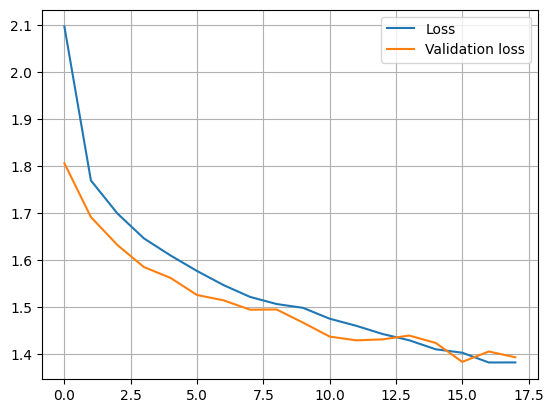

In [69]:
plt.plot(history.history["loss"], label="Loss")
plt.plot(history.history["val_loss"], label="Validation loss")
plt.legend()
plt.grid()
plt.show()

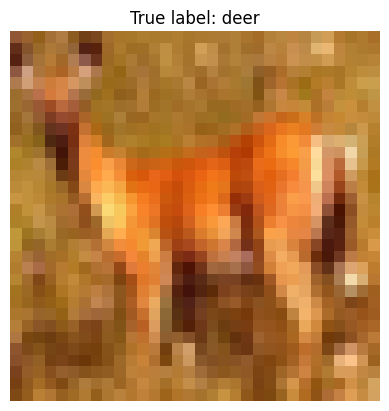

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
Predicted: deer


In [66]:
import matplotlib.pyplot as plt

class_names = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

idx = 110
img = x_test[idx].reshape(32, 32, 3)  # palautetaan muotoon

plt.imshow(img)
plt.title(f"True label: {class_names[y_test[idx][0]]}")
plt.axis("off")
plt.show()

# Ennuste
pred = model.predict(x_test[idx:idx+1])
print("Predicted:", class_names[np.argmax(pred)])